In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip3 install --upgrade keras

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.2/311.2 kB 35.7 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 2.15.0
    Uninstalling keras-2.15.0:
      Successfully uninstalled keras-2.15.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.15.0 requires keras<2.16,>=2.15.0, but you have keras 3.4.0 which is incompatible.


In [ ]:
import keras
import tensorflow as tf

from keras import layers as tfkl
from keras import ops
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
dataset = np.concatenate([x_train,x_test])
dataset = dataset/255.0
dataset = np.expand_dims(dataset , axis = -1)
print(dataset.shape)

(70000, 28, 28, 1)


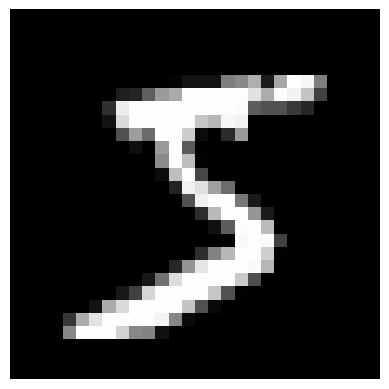

In [ ]:
for x in dataset:
    plt.axis("off")
    plt.imshow((x * 255).astype("int32"), cmap = 'gray')
    break

In [ ]:
discriminator_net = keras.Sequential(
    [
        keras.Input(shape = (28,28,1)),
        tfkl.Conv2D(filters = 64 , kernel_size = 4 , strides = 2 , padding = 'same'),
        tfkl.LeakyReLU(negative_slope=0.2),
        tfkl.Conv2D(filters = 128 , kernel_size = 4 , strides = 2 , padding = 'same'),
        tfkl.LeakyReLU(negative_slope=0.2),
        tfkl.Conv2D(filters = 128 , kernel_size = 4 , strides = 2 , padding = 'same'),
        tfkl.LeakyReLU(negative_slope=0.2),
        tfkl.Flatten(),
        tfkl.Dropout(0.2),
        tfkl.Dense(1 , activation = 'sigmoid')
    ],
    name = 'Discriminator',
)
discriminator_net.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 14, 14, 64)          │           1,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_6 (LeakyReLU)            │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 7, 7, 128)           │         131,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_7 (LeakyReLU)            │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 4, 4, 128)           │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_8 (LeakyReLU)            │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │           2,049 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 396,609 (1.51 MB)

 Trainable params: 396,609 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
latent_dim = 50

generator = keras.Sequential(
    [
        keras.Input(shape=(latent_dim,)),
        tfkl.Dense(3 * 3 * 128),
        tfkl.Reshape((3, 3, 128)),
        tfkl.Conv2DTranspose(128, kernel_size=4, strides=2, padding="same"),
        tfkl.LeakyReLU(negative_slope=0.2),
        tfkl.Conv2DTranspose(256, kernel_size=4, strides=2, padding="valid"),
        tfkl.LeakyReLU(negative_slope=0.2),
        tfkl.Conv2DTranspose(512, kernel_size=4, strides=2, padding="same"),
        tfkl.LeakyReLU(negative_slope=0.2),
        tfkl.Conv2D(1, kernel_size=5, padding="same", activation="sigmoid"),
    ],
    name="generator",
)
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                      │ (None, 1152)                │          58,752 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 3, 3, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose (Conv2DTranspose)   │ (None, 6, 6, 128)           │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_3 (LeakyReLU)            │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_1 (Conv2DTranspose) │ (None, 14, 14, 256)         │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_4 (LeakyReLU)            │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_2 (Conv2DTranspose) │ (None, 28, 28, 512)         │       2,097,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_5 (LeakyReLU)            │ (None, 28, 28, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 1)           │          12,801 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,956,033 (11.28 MB)

 Trainable params: 2,956,033 (11.28 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

class GAN(keras.Model):
    def __init__(self, discriminator, generator, latent_dim):
        super().__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim
        self.seed_generator = keras.random.SeedGenerator(1337)

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super().compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn
        self.d_loss_metric = keras.metrics.Mean(name="d_loss")
        self.g_loss_metric = keras.metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric]

    def train_step(self, real_images):
        # Sample random points in the latent space
        batch_size = ops.shape(real_images)[0]
        random_latent_vectors = keras.random.normal(
            shape=(batch_size, self.latent_dim), seed=self.seed_generator
        )

        # Decode them to fake images
        generated_images = self.generator(random_latent_vectors)

        # Combine them with real images
        combined_images = ops.concatenate([generated_images, real_images], axis=0)

        # Assemble labels discriminating real from fake images
        labels = ops.concatenate(
            [ops.ones((batch_size, 1)), ops.zeros((batch_size, 1))], axis=0
        )
        # Add random noise to the labels
        labels += 0.05 * tf.random.uniform(tf.shape(labels))

        # Train the discriminator
        with tf.GradientTape() as tape:
            predictions = self.discriminator(combined_images)
            d_loss = self.loss_fn(labels, predictions)
        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(
            zip(grads, self.discriminator.trainable_weights)
        )

        # Sample random points in the latent space
        random_latent_vectors = keras.random.normal(
            shape=(batch_size, self.latent_dim), seed=self.seed_generator
        )

        # Assemble labels that say "all real images"
        misleading_labels = ops.zeros((batch_size, 1))

        # Train the generator (note that we should *not* update the weights
        # of the discriminator)!
        with tf.GradientTape() as tape:
            predictions = self.discriminator(self.generator(random_latent_vectors))
            g_loss = self.loss_fn(misleading_labels, predictions)
        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_weights))

        # Update metrics
        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)
        return {
            "d_loss": self.d_loss_metric.result(),
            "g_loss": self.g_loss_metric.result(),
        }

In [ ]:
class GANMonitor(keras.callbacks.Callback):
    def __init__(self, num_img=3, latent_dim=128):
        self.num_img = num_img
        self.latent_dim = latent_dim
        self.seed_generator = keras.random.SeedGenerator(42)

    def on_epoch_end(self, epoch, logs=None):
        random_latent_vectors = keras.random.normal(
            shape=(self.num_img, self.latent_dim), seed=self.seed_generator
        )
        generated_images = self.model.generator(random_latent_vectors)
        generated_images *= 255
        generated_images.numpy()
        for i in range(self.num_img):
            img = keras.utils.array_to_img(generated_images[i])
            img.save("generated_img_%03d_%d.png" % (epoch, i))

In [ ]:
epochs = 10

gan = GAN(discriminator=discriminator_net, generator=generator, latent_dim=latent_dim)
gan.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    g_optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss_fn=keras.losses.BinaryCrossentropy(),
)

gan.fit(
    dataset, epochs=epochs, callbacks=[GANMonitor(num_img=10, latent_dim=latent_dim)]
)

Epoch 1/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 145s 58ms/step - d_loss: 0.6738 - g_loss: 16.1535
Epoch 2/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 127s 58ms/step - d_loss: 0.5137 - g_loss: 1.3136
Epoch 3/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 140s 57ms/step - d_loss: 0.5554 - g_loss: 1.5443
Epoch 4/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 125s 57ms/step - d_loss: 0.5867 - g_loss: 1.1232
Epoch 5/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 125s 57ms/step - d_loss: 0.6170 - g_loss: 1.0092
Epoch 6/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 143s 58ms/step - d_loss: 0.6272 - g_loss: 0.9508
Epoch 7/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 125s 57ms/step - d_loss: 0.6360 - g_loss: 0.9369
Epoch 8/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 125s 57ms/step - d_loss: 0.6453 - g_loss: 0.9069
Epoch 9/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 125s 57ms/step - d_loss: 0.6434 - g_loss: 0.9213
Epoch 10/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 142s 57ms/step - d_loss: 0.6465 - g_loss: 0.8932


In [ ]:
gan.generator.save("/content/drive/MyDrive/Colab Notebooks/gan_gen.keras")

In [ ]:
gan.discriminator.save("/content/drive/MyDrive/Colab Notebooks/gan_disc.keras")